In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import eigh
from statsmodels.api import OLS, add_constant
import yfinance as yf

In [20]:
# ---------------------------
# 参数
# ---------------------------
lookback = 252
num_factors = 5
topN = 50

In [21]:
# ---------------------------
# 工具函数
# ---------------------------
def lag1(x):
    return x.shift(1)

def smartmean(x, axis=0):
    return np.nanmean(x, axis=axis)

def smartcov(x):
    """
    x: shape (T, N)
    rows = observations, columns = variables
    normalize by N (not N-1)
    """
    x = np.asarray(x)
    mu = np.nanmean(x, axis=0)
    xc = x - mu

    cov = np.nanmean(
        xc[:, :, None] * xc[:, None, :],
        axis=0
    )
    return cov

In [22]:
# ---------------------------
# 数据准备
# ---------------------------
symbols = [
    "SMCI", "ATI", "ELF", "CROX", "FNKO",
    "BOOT", "CAL", "GEO", "VRT", "SNDR"
]

symbols = [s.replace(".", "-") for s in symbols]

cl = yf.download(
    symbols,
    start="2015-01-01",
    end="2024-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

cl = cl.sort_index()
cl = cl.dropna(how="all", axis=1)

mycls = cl.ffill()
mycls

Ticker,ATI,BOOT,CAL,CROX,ELF,FNKO,GEO,SMCI,SNDR,VRT
Date,,,,,,,,,,
2015-01-02,32.917789,17.940001,27.074347,12.490000,NaN,NaN,15.302589,3.473000,NaN,NaN
2015-01-05,31.012983,18.000000,26.884829,12.610000,NaN,NaN,15.400517,3.367000,NaN,NaN
2015-01-06,30.237659,18.290001,25.635773,12.080000,NaN,NaN,15.325187,3.276000,NaN,NaN
2015-01-07,30.773689,18.540001,26.600569,11.700000,NaN,NaN,15.505972,3.300000,NaN,NaN
2015-01-08,30.945982,19.299999,27.539511,11.820000,NaN,NaN,15.536105,3.473000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-12-22,45.610001,77.150002,29.692249,98.180000,143.839996,7.14,11.230000,28.972000,24.982935,48.652306
2023-12-26,46.250000,78.669998,30.401983,96.699997,143.740005,7.20,11.150000,29.433001,25.060553,48.861759
2023-12-27,46.180000,78.779999,30.713102,94.510002,144.050003,7.26,11.150000,29.500000,24.759785,48.801914


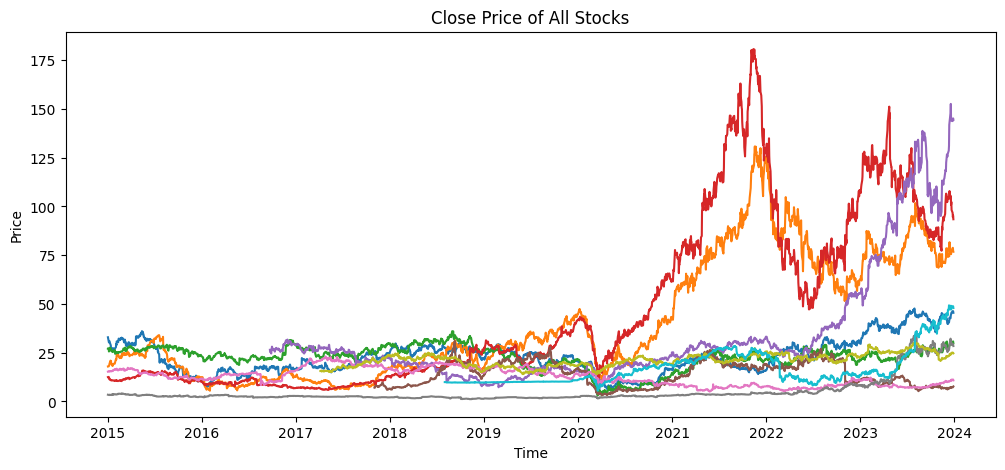

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(mycls)
plt.title("Close Price of All Stocks")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [42]:
dailyret = (mycls - lag1(mycls)) / lag1(mycls)
dailyret = dailyret.dropna()

In [66]:
positions = pd.DataFrame(
    0,
    index=dailyret.index,
    columns=dailyret.columns
)

# ---------------------------
# 主循环
# ---------------------------
eigvals_matrix = []
top_factor = []
for t in range(lookback, len(dailyret)):
    window = dailyret.iloc[t - lookback:t]

    # R: shape (N, T)
    R = window.T.values

    # 去掉有缺失的股票
    has_data = np.all(np.isfinite(R), axis=1)
    R = R[has_data]

    avgR = smartmean(R, axis=1)

    # 去均值
    R = R - avgR[:, None]

    # 协方差矩阵
    covR = smartcov(R.T)

    # PCA（协方差矩阵是对称的，用 eigh）
    eigvals, eigvecs = eigh(covR)
    eigvals_matrix.append(eigvals)

    # 取最大 num_factors 个特征向量
    X = eigvecs[:, -num_factors:]
    top_factor.append(

    # t-1 → t 的因子收益
    y = R[:, -1]
    b = np.linalg.lstsq(X, y, rcond=None)[0]

    # 预测下一期收益
    Rexp = avgR + X @ b

    order = np.argsort(Rexp)

    stk_idx = np.where(has_data)[0]
    short_idx = stk_idx[order[:topN]]
    long_idx = stk_idx[order[-topN:]]

    positions.iloc[t, short_idx] = -1
    positions.iloc[t, long_idx] = 1


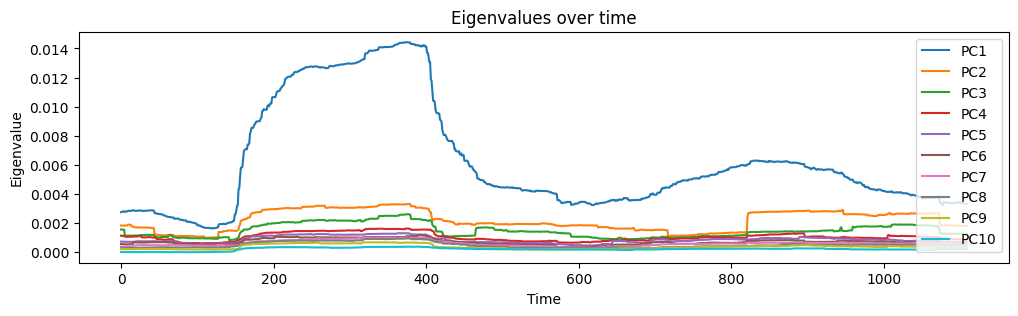

In [87]:
eigvals_matrix = np.array(eigvals_matrix)
plt.figure(figsize=(12, 3))
for i in range(eigvals_matrix.shape[1]):
    plt.plot(eigvals_matrix[:, eigvals_matrix.shape[1]-1-i], label=f"PC{i+1}")
plt.legend()
plt.title("Eigenvalues over time")
plt.xlabel("Time")
plt.ylabel("Eigenvalue")
plt.show()

In [ ]:
可以看到，第一个eigen vector的eigen value比其他eigen value大太多，特别是

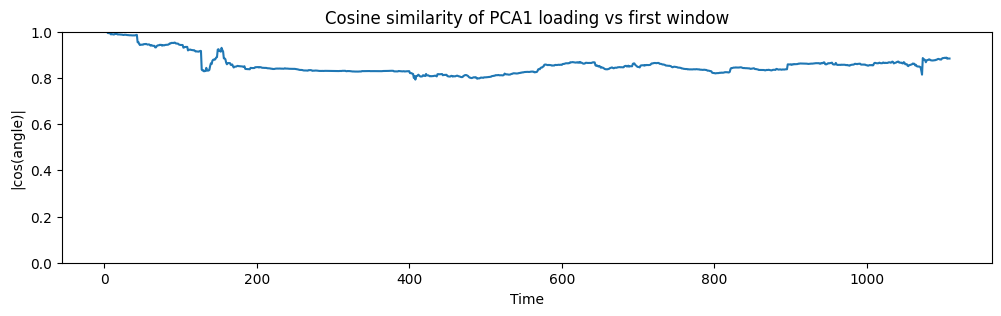

In [85]:
top_factor = np.array(top_factor)   # shape: (T, N)

# 取第一期作为基准
v0 = top_factor[0]
v0 = v0 / np.linalg.norm(v0)

cos_sim = []
for t in range(len(top_factor)):
    vt = top_factor[t]
    vt = vt / np.linalg.norm(vt)
    cos_sim.append(np.abs(np.dot(v0, vt)))  # abs 解决正负翻转

plt.figure(figsize=(12,3))
plt.plot(cos_sim)
plt.title("Cosine similarity of PCA1 loading vs first window")
plt.ylabel("|cos(angle)|")
plt.xlabel("Time")
plt.ylim(0.5, 1)
plt.show()


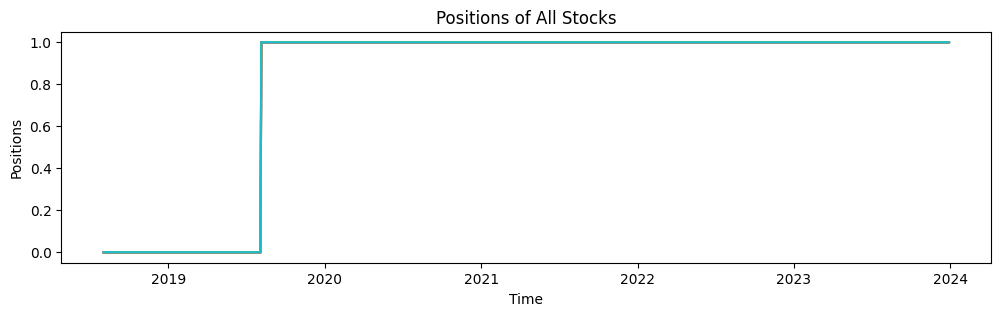

In [48]:
plt.figure(figsize=(12,3))
plt.plot(positions)
plt.title("Positions of All Stocks")
plt.xlabel("Time")
plt.ylabel("Positions")
plt.show()

In [45]:
# ---------------------------
# 策略收益
# ---------------------------
gross_exposure = positions.abs().sum(axis=1)
ret = (positions.shift(1) * dailyret).sum(axis=1) / gross_exposure.shift(1)
avgret = ret.mean() * 252

print("Annualized return:", avgret)

Annualized return: 0.4011605107374583


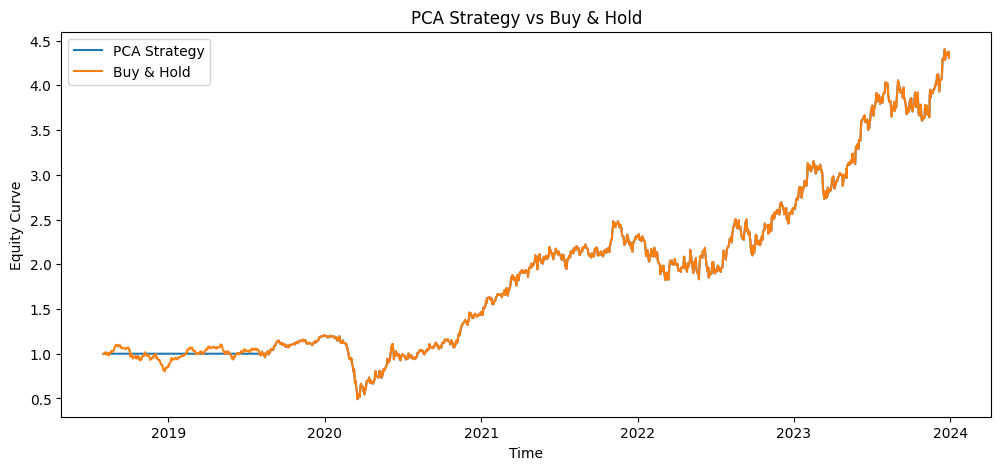

In [46]:
import matplotlib.pyplot as plt

# Buy & Hold：等权持有所有股票
bh_ret = dailyret.mean(axis=1)

# 累计净值
eq_strategy = (1 + ret.fillna(0)).cumprod()
eq_bh = (1 + bh_ret.fillna(0)).cumprod()

# 对齐时间
df = eq_strategy.to_frame("PCA Strategy").join(
    eq_bh.to_frame("Buy & Hold"),
    how="inner"
)

# 画图（单图，不指定颜色）
plt.figure(figsize=(12,5))
plt.plot(df.index, df["PCA Strategy"], label="PCA Strategy")
plt.plot(df.index, df["Buy & Hold"], label="Buy & Hold")
plt.title("PCA Strategy vs Buy & Hold")
plt.xlabel("Time")
plt.ylabel("Equity Curve")
plt.legend()
plt.show()
